In [1]:
from gensim.downloader import load
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [3]:
# Load a small pre-trained word vector model
model = load("glove-wiki-gigaword-50")  # 50D embeddings, small and fast
words = ['king', 'queen', 'man', 'woman', 'apple', 'orange', 'car', 'bus']

# Build the matrix
sim_matrix = np.zeros((len(words), len(words)))

for i in range(len(words)):
    for j in range(len(words)):
        sim_matrix[i][j] = cosine_similarity(model[words[i]], model[words[j]])

[==================================================] 100.0% 66.0/66.0MB downloaded


In [4]:
sim_matrix

array([[1.00000012, 0.78390431, 0.53093773, 0.41133785, 0.30468503,
        0.2575278 , 0.262566  , 0.21246062],
       [0.78390431, 1.00000012, 0.53667003, 0.60031056, 0.20420702,
        0.40583566, 0.28833503, 0.2905854 ],
       [0.53093773, 0.53667003, 1.        , 0.88603371, 0.24861859,
        0.34215409, 0.57973766, 0.44311753],
       [0.41133785, 0.60031056, 0.88603371, 1.        , 0.21642959,
        0.35483488, 0.50113809, 0.42724195],
       [0.30468503, 0.20420702, 0.24861859, 0.21642959, 1.00000012,
        0.53880411, 0.39515424, 0.19062528],
       [0.2575278 , 0.40583566, 0.34215409, 0.35483488, 0.53880411,
        0.99999994, 0.37214023, 0.32641321],
       [0.262566  , 0.28833503, 0.57973766, 0.50113809, 0.39515424,
        0.37214023, 1.        , 0.821051  ],
       [0.21246062, 0.2905854 , 0.44311753, 0.42724195, 0.19062528,
        0.32641321, 0.821051  , 0.99999994]])

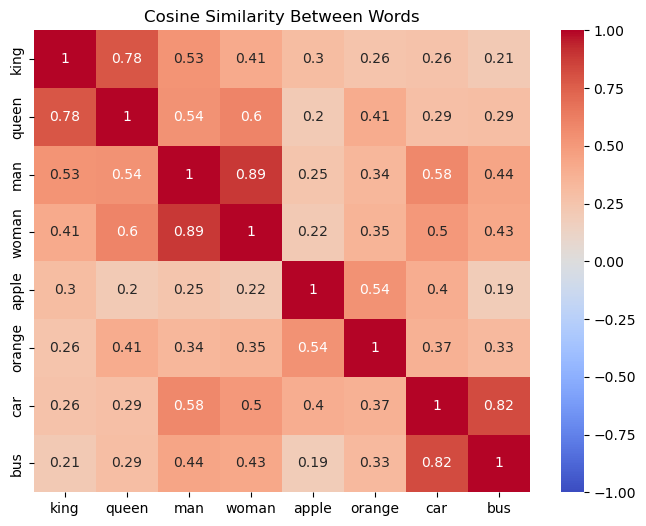

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, xticklabels=words, yticklabels=words, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Cosine Similarity Between Words")
plt.show()

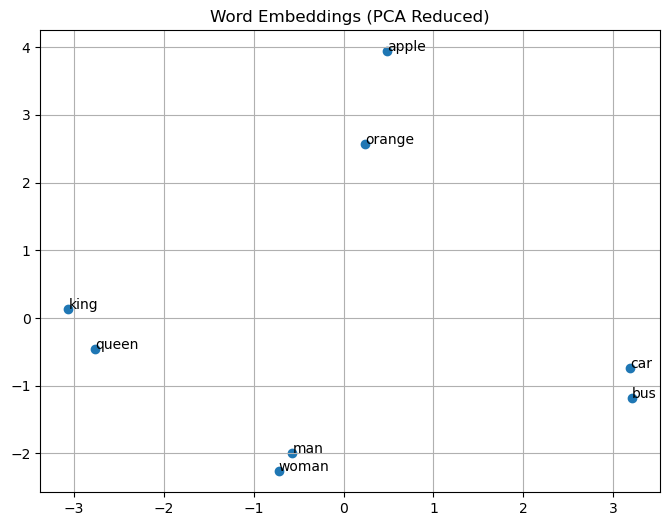

In [6]:
from sklearn.decomposition import PCA

vectors = np.array([model[word] for word in words])
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]))

plt.title("Word Embeddings (PCA Reduced)")
plt.grid(True)
plt.show()

### Explanation:

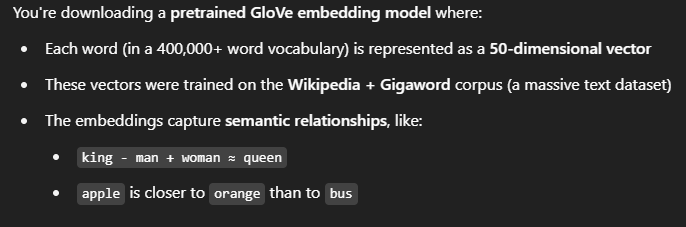

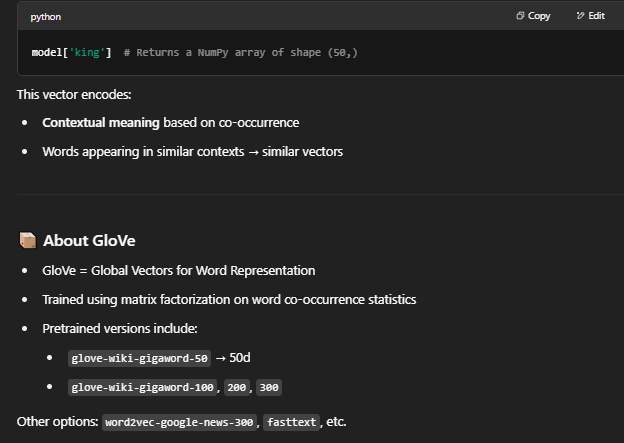